In [76]:
import os
os.chdir("/Users/caiwansun/Downloads/timeline-example-caiwan")
os.getcwd()

'/Users/caiwansun/Downloads/timeline-example-caiwan'

In [78]:
with open("samples-data/data-final/d2g2-segments-messi-gpt4-enact.json") as f:
    data = json.load(f)

print(type(data))
print(data)

<class 'dict'>
{'type': 'text', 'id': 'd2g2-segments-messi-gpt4-enact', 'algorithm': 'LLM', 'processor': 'ChatGPT', 'processed': 1772656502187, 'version': 1, 'localisation': [{'sublocalisations': {'localisation': [{'tclevel': 1, 'tcin': '00:00:07.0000', 'tcout': '00:00:19.0000', 'label': 'ENACTING MESSI'}, {'tclevel': 1, 'tcin': '00:00:07.0000', 'tcout': '00:00:23.0000', 'label': 'ENACTING MESSI'}, {'tclevel': 1, 'tcin': '00:00:07.0000', 'tcout': '00:00:23.0000', 'label': 'ENACTING MESSI'}, {'tclevel': 1, 'tcin': '00:00:07.0000', 'tcout': '00:00:31.0000', 'label': 'ENACTING MESSI'}, {'tclevel': 1, 'tcin': '00:00:07.0000', 'tcout': '00:00:31.0000', 'label': 'ENACTING MESSI'}, {'tclevel': 1, 'tcin': '00:00:07.0000', 'tcout': '00:00:46.0000', 'label': 'ENACTING MESSI'}, {'tclevel': 1, 'tcin': '00:00:07.0000', 'tcout': '00:00:46.0000', 'label': 'ENACTING MESSI'}, {'tclevel': 1, 'tcin': '00:00:07.0000', 'tcout': '00:00:51.0000', 'label': 'ENACTING MESSI'}, {'tclevel': 1, 'tcin': '00:00:15.0

In [80]:
#Method1:All pairs comparison
import json

def classify(a_start, a_end, b_start, b_end):

    if a_start == b_start and a_end == b_end:
        return "EXACT_MATCH"

    if a_start == b_start:
        return "SAME_START"

    if a_end == b_end:
        return "SAME_END"

    if b_start <= a_start and b_end >= a_end:
        return "GPT52_CONTAINS_GPT4"

    if a_start <= b_start and a_end >= b_end:
        return "GPT4_CONTAINS_GPT52"

    if a_start < b_end and a_end > b_start:
        return "PARTIAL_OVERLAP"

    return "NO_OVERLAP"


# load json
with open("samples-data/data-final/d2g2-segments-messi-gpt4-enact.json") as f:
    data4 = json.load(f)

gpt4 = data4["localisation"][0]["sublocalisations"]["localisation"]

with open("samples-data/data-final/d2g2-segments-messi-gpt52-enact.json") as f:
    data52 = json.load(f)

gpt52 = data52["localisation"][0]["sublocalisations"]["localisation"]

print(len(gpt4), len(gpt52))
print(gpt4[0])

def tc_to_seconds(tc):
    h, m, s = tc.split(":")
    return int(h)*3600 + int(m)*60 + float(s)


results = []

for seg4 in gpt4:

    a_start = tc_to_seconds(seg4["tcin"])
    a_end = tc_to_seconds(seg4["tcout"])

    for seg52 in gpt52:

        b_start = tc_to_seconds(seg52["tcin"])
        b_end = tc_to_seconds(seg52["tcout"])

        relation = classify(a_start, a_end, b_start, b_end)

        results.append({
                "gpt4": [a_start, a_end],
                "gpt52": [b_start, b_end],
                "relation": relation
        })


print("Total relations:", len(results))

for r in results[:20]:
    print(r)

43 189
{'tclevel': 1, 'tcin': '00:00:07.0000', 'tcout': '00:00:19.0000', 'label': 'ENACTING MESSI'}
Total relations: 8127
{'gpt4': [7.0, 19.0], 'gpt52': [7.0, 9.0], 'relation': 'SAME_START'}
{'gpt4': [7.0, 19.0], 'gpt52': [7.0, 19.0], 'relation': 'EXACT_MATCH'}
{'gpt4': [7.0, 19.0], 'gpt52': [7.0, 23.0], 'relation': 'SAME_START'}
{'gpt4': [7.0, 19.0], 'gpt52': [7.0, 23.0], 'relation': 'SAME_START'}
{'gpt4': [7.0, 19.0], 'gpt52': [7.0, 31.0], 'relation': 'SAME_START'}
{'gpt4': [7.0, 19.0], 'gpt52': [7.0, 31.0], 'relation': 'SAME_START'}
{'gpt4': [7.0, 19.0], 'gpt52': [7.0, 34.0], 'relation': 'SAME_START'}
{'gpt4': [7.0, 19.0], 'gpt52': [7.0, 41.0], 'relation': 'SAME_START'}
{'gpt4': [7.0, 19.0], 'gpt52': [7.0, 46.0], 'relation': 'SAME_START'}
{'gpt4': [7.0, 19.0], 'gpt52': [7.0, 46.0], 'relation': 'SAME_START'}
{'gpt4': [7.0, 19.0], 'gpt52': [7.0, 48.0], 'relation': 'SAME_START'}
{'gpt4': [7.0, 19.0], 'gpt52': [7.0, 51.0], 'relation': 'SAME_START'}
{'gpt4': [7.0, 19.0], 'gpt52': [7.0, 7

In [82]:
from collections import Counter

counter = Counter(r["relation"] for r in results)

print("\nRelation statistics:")
for k,v in counter.items():
    print(k, ":", v)


Relation statistics:
SAME_START : 1802
EXACT_MATCH : 63
PARTIAL_OVERLAP : 80
NO_OVERLAP : 5564
GPT4_CONTAINS_GPT52 : 75
GPT52_CONTAINS_GPT4 : 538
SAME_END : 5


In [84]:
##Method2:Best match
def overlap(a_start, a_end, b_start, b_end):
    return max(0, min(a_end, b_end) - max(a_start, b_start))


matches = []

for i, seg4 in enumerate(gpt4):

    a_start = tc_to_seconds(seg4["tcin"])
    a_end = tc_to_seconds(seg4["tcout"])

    best_overlap = 0
    best_seg = None
    best_j = None

    for j, seg52 in enumerate(gpt52):

        b_start = tc_to_seconds(seg52["tcin"])
        b_end = tc_to_seconds(seg52["tcout"])

        ov = overlap(a_start, a_end, b_start, b_end)

        if ov > best_overlap:
            best_overlap = ov
            best_seg = (b_start, b_end)
            best_j = j + 1

    relation = classify(a_start, a_end, best_seg[0], best_seg[1])

    matches.append({
        "GPT4_id": i+1,
        "GPT4_segment": [a_start, a_end],
        "GPT52_id": best_j,
        "GPT52_segment": best_seg,
        "relation": relation
    })

In [86]:
print("Total matches:", len(matches))

for m in matches:
    print(m)

Total matches: 43
{'GPT4_id': 1, 'GPT4_segment': [7.0, 19.0], 'GPT52_id': 2, 'GPT52_segment': (7.0, 19.0), 'relation': 'EXACT_MATCH'}
{'GPT4_id': 2, 'GPT4_segment': [7.0, 23.0], 'GPT52_id': 3, 'GPT52_segment': (7.0, 23.0), 'relation': 'EXACT_MATCH'}
{'GPT4_id': 3, 'GPT4_segment': [7.0, 23.0], 'GPT52_id': 3, 'GPT52_segment': (7.0, 23.0), 'relation': 'EXACT_MATCH'}
{'GPT4_id': 4, 'GPT4_segment': [7.0, 31.0], 'GPT52_id': 5, 'GPT52_segment': (7.0, 31.0), 'relation': 'EXACT_MATCH'}
{'GPT4_id': 5, 'GPT4_segment': [7.0, 31.0], 'GPT52_id': 5, 'GPT52_segment': (7.0, 31.0), 'relation': 'EXACT_MATCH'}
{'GPT4_id': 6, 'GPT4_segment': [7.0, 46.0], 'GPT52_id': 9, 'GPT52_segment': (7.0, 46.0), 'relation': 'EXACT_MATCH'}
{'GPT4_id': 7, 'GPT4_segment': [7.0, 46.0], 'GPT52_id': 9, 'GPT52_segment': (7.0, 46.0), 'relation': 'EXACT_MATCH'}
{'GPT4_id': 8, 'GPT4_segment': [7.0, 51.0], 'GPT52_id': 12, 'GPT52_segment': (7.0, 51.0), 'relation': 'EXACT_MATCH'}
{'GPT4_id': 9, 'GPT4_segment': [15.0, 38.0], 'GPT52_i

In [88]:
##Method3:One-to-Many Overlap Mapping
results = []

for i, seg4 in enumerate(gpt4):

    a_start = tc_to_seconds(seg4["tcin"])
    a_end = tc_to_seconds(seg4["tcout"])

    related_segments = []

    for j, seg52 in enumerate(gpt52):

        b_start = tc_to_seconds(seg52["tcin"])
        b_end = tc_to_seconds(seg52["tcout"])

        relation = classify(a_start, a_end, b_start, b_end)

        if relation != "NO_OVERLAP":

            related_segments.append({
                "GPT52_id": j+1,
                "segment": [b_start, b_end],
                "relation": relation
            })

    results.append({
        "GPT4_id": i+1,
        "GPT4_segment": [a_start, a_end],
        "related_GPT52": related_segments
    })

In [90]:
for r in results[:3]:
    print("GPT4_", r["GPT4_id"], r["GPT4_segment"])

    for seg in r["related_GPT52"]:
        print("   → GPT52_", seg["GPT52_id"], seg["segment"], seg["relation"])

GPT4_ 1 [7.0, 19.0]
   → GPT52_ 1 [7.0, 9.0] SAME_START
   → GPT52_ 2 [7.0, 19.0] EXACT_MATCH
   → GPT52_ 3 [7.0, 23.0] SAME_START
   → GPT52_ 4 [7.0, 23.0] SAME_START
   → GPT52_ 5 [7.0, 31.0] SAME_START
   → GPT52_ 6 [7.0, 31.0] SAME_START
   → GPT52_ 7 [7.0, 34.0] SAME_START
   → GPT52_ 8 [7.0, 41.0] SAME_START
   → GPT52_ 9 [7.0, 46.0] SAME_START
   → GPT52_ 10 [7.0, 46.0] SAME_START
   → GPT52_ 11 [7.0, 48.0] SAME_START
   → GPT52_ 12 [7.0, 51.0] SAME_START
   → GPT52_ 13 [7.0, 71.0] SAME_START
   → GPT52_ 14 [7.0, 90.0] SAME_START
   → GPT52_ 15 [7.0, 91.0] SAME_START
   → GPT52_ 16 [7.0, 93.0] SAME_START
   → GPT52_ 17 [7.0, 96.0] SAME_START
   → GPT52_ 18 [7.0, 101.0] SAME_START
   → GPT52_ 19 [7.0, 101.0] SAME_START
   → GPT52_ 20 [7.0, 106.0] SAME_START
   → GPT52_ 21 [7.0, 111.0] SAME_START
   → GPT52_ 22 [7.0, 111.0] SAME_START
   → GPT52_ 23 [7.0, 113.0] SAME_START
   → GPT52_ 24 [7.0, 114.0] SAME_START
   → GPT52_ 25 [7.0, 117.0] SAME_START
   → GPT52_ 26 [7.0, 121.0] SAM

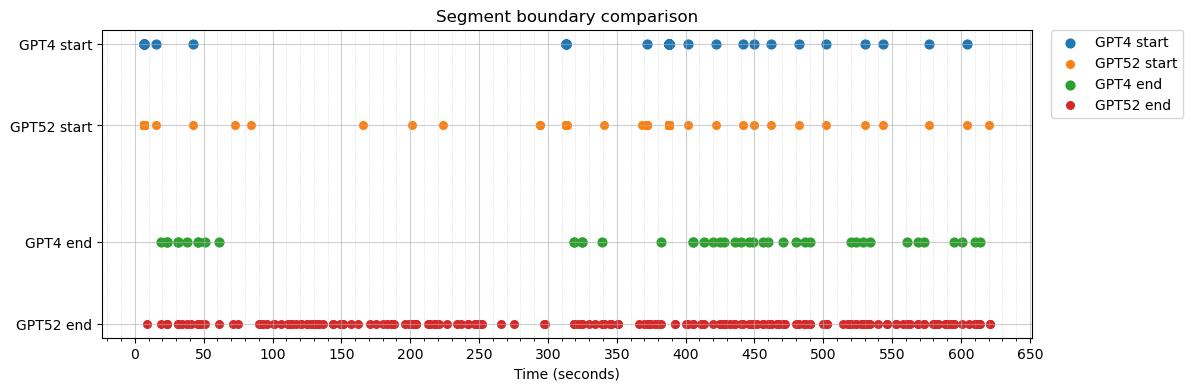

In [92]:
##Method4:Segment Boundary Alignment Visualization
plt.figure(figsize=(12,4))

plt.scatter(starts4, [2.6]*len(starts4), s=40, label="GPT4 start")
plt.scatter(starts52, [1.9]*len(starts52), s=30, label="GPT52 start")

plt.scatter(ends4, [0.9]*len(ends4), s=40, label="GPT4 end")
plt.scatter(ends52, [0.2]*len(ends52), s=30, label="GPT52 end")

plt.yticks([2.6,1.9,0.9,0.2], ["GPT4 start","GPT52 start","GPT4 end","GPT52 end"])

plt.xlabel("Time (seconds)")
plt.title("Segment boundary comparison")

from matplotlib.ticker import MultipleLocator
ax = plt.gca()

ax.xaxis.set_major_locator(MultipleLocator(50))
ax.xaxis.set_minor_locator(MultipleLocator(10))

ax.grid(which='major', linestyle='-', linewidth=0.8, alpha=0.6)
ax.grid(which='minor', linestyle=':', linewidth=0.5, alpha=0.6)

plt.legend(
    loc="upper left",
    bbox_to_anchor=(1.02, 1),
    borderaxespad=0
)

plt.show()